# Gesture Recognition — Training (All Gestures incl. Optionals)

Trains a neural network for the **full gesture set** (7 classes):
- Mandatory: idle, sl, sr, r_cw
- O3: r_ccw (rotate anticlockwise)
- O5: su (swipe up), sd (swipe down)

This model is used for **M3** (live video prediction + slideshow control).

**Prerequisites:** Run `gesture_recognition_preproc_optionals.ipynb` for all 3 teammates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path('.').resolve()))

from ml_framework.layers.activations import relu, relu_derivative, softmax
from ml_framework.metrics import accuracy, f1_score, confusion_matrix as confusion_matrix_np
from ml_framework.visualization.training_plots import plot_metrics, plot_confusion_matrix
from ml_framework.visualization.comparison_plots import plot_model_comparison, plot_multi_model_summary
from ml_framework.utils import (
    save_training_history, load_training_history, load_multiple_histories,
)

from adam_neural_net import NeuralNetwork

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROCESSED_DIR = Path("../data/processed")
EDA_DIR = Path("../visualizations/training")
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"Visualizations will be saved to: {EDA_DIR.resolve()}")

Imports OK
Visualizations will be saved to: C:\Users\Aswathy\Documents\jmu\WS25\ML Project\final_project_latest\final-submission\visualizations\training


## Step 1: Load & Combine Preprocessed Data

In [2]:
files = {
    "arun": PROCESSED_DIR / "arun_preprocessed.csv",
    "aswathy": PROCESSED_DIR / "aswathy_preprocessed.csv",
    "nayana": PROCESSED_DIR / "nayana_preprocessed.csv",
}

dfs = {}
for name, path in files.items():
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f"{name}: {dfs[name].shape} | labels: {dict(dfs[name]['label'].value_counts())}")
    else:
        print(f"WARNING: {path} not found")

combined_df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined: {combined_df.shape}")
print(combined_df["label"].value_counts())

arun: (5082, 94) | labels: {'idle': np.int64(3767), 'sd': np.int64(294), 'su': np.int64(273), 'r_ccw': np.int64(256), 'r_cw': np.int64(233), 'sr': np.int64(136), 'sl': np.int64(123)}
aswathy: (4947, 94) | labels: {'idle': np.int64(3829), 'sd': np.int64(305), 'su': np.int64(232), 'r_ccw': np.int64(191), 'r_cw': np.int64(189), 'sr': np.int64(103), 'sl': np.int64(98)}
nayana: (5220, 94) | labels: {'idle': np.int64(4032), 'sd': np.int64(294), 'su': np.int64(259), 'r_ccw': np.int64(169), 'r_cw': np.int64(164), 'sr': np.int64(157), 'sl': np.int64(145)}

Combined: (15249, 94)
label
idle     11628
sd         893
su         764
r_ccw      616
r_cw       586
sr         396
sl         366
Name: count, dtype: int64


## Step 2: Keep All Gesture Labels

Unlike the mandatory notebook, we keep all 7 classes here.

In [3]:
ALL_LABELS = {"idle", "sl", "sr", "r_cw", "r_ccw", "su", "sd"}

before = len(combined_df)
combined_df = combined_df[combined_df["label"].isin(ALL_LABELS)].reset_index(drop=True)
print(f"Filtered: {before} -> {len(combined_df)} (kept all valid labels)")
print(combined_df["label"].value_counts())

Filtered: 15249 -> 15249 (kept all valid labels)
label
idle     11628
sd         893
su         764
r_ccw      616
r_cw       586
sr         396
sl         366
Name: count, dtype: int64


## Step 3: Create Sliding Windows

In [4]:
TARGET_FPS = 30
WINDOW_SIZE = 18  # 0.6s at 30 FPS
STRIDE = 2        # smaller stride → more windows for minority classes

NON_FEATURES = {"gesture_type", "ground_truth", "label", "person", "source_file", "time"}
feature_cols = [c for c in combined_df.columns if c not in NON_FEATURES]
print(f"Feature columns: {len(feature_cols)}")

# Position features = first half (45 cols: 15 keypoints × 3 axes)
N_POS = len(feature_cols) // 2   # = 45

def make_windows(df, feature_cols, window, stride):
    """Sliding windows with per-frame pos+vel AND net displacement appended.

    Net displacement (final_pos - initial_pos over the window) is the key
    discriminator for the three confusing classes:
      su  -> wrist Y net large negative  (wrist rose)
      sd  -> wrist Y net large positive  (wrist fell)
      r_cw-> net displacement ≈ 0        (circular motion, returns to start)
    Window feature size: window * len(feature_cols) + N_POS
    = 18 * 90 + 45 = 1665
    """
    X_all, y_all = [], []
    mid = window // 2
    n_pos = len(feature_cols) // 2
    for _, g in df.groupby("source_file"):
        g = g.sort_values("time").reset_index(drop=True)
        feats = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy()
        if len(g) < window:
            continue
        for start in range(0, len(g) - window + 1, stride):
            win = feats[start:start+window]
            net_disp = win[-1, :n_pos] - win[0, :n_pos]   # shape (45,)
            X_all.append(np.concatenate([win.flatten(), net_disp]))
            y_all.append(labels[start + mid])
    return np.stack(X_all), np.array(y_all)

X_win, y_win = make_windows(combined_df, feature_cols, WINDOW_SIZE, STRIDE)
print(f"X_win: {X_win.shape}, y_win: {y_win.shape}")
print(f"  Per-window: {WINDOW_SIZE}×{len(feature_cols)} + {N_POS} net_disp = {X_win.shape[1]}")
print(f"Labels: {dict(zip(*np.unique(y_win, return_counts=True)))}")

Feature columns: 90
X_win: (7475, 1665), y_win: (7475,)
  Per-window: 18×90 + 45 net_disp = 1665
Labels: {np.str_('idle'): np.int64(5665), np.str_('r_ccw'): np.int64(310), np.str_('r_cw'): np.int64(293), np.str_('sd'): np.int64(445), np.str_('sl'): np.int64(183), np.str_('sr'): np.int64(198), np.str_('su'): np.int64(381)}


## Step 4: Balance + Label Encode + Flatten + Split + Standardize

In [5]:
# ---- Balance: undersample idle + oversample minority gestures ----
y = np.array([str(v) for v in y_win])
idle_idx = np.where(y == "idle")[0]
gesture_idx = np.where(y != "idle")[0]

IDLE_RATIO = 1.5
target_idle = min(len(idle_idx), int(IDLE_RATIO * len(gesture_idx)))
rng = np.random.default_rng(42)
idle_keep = rng.choice(idle_idx, size=target_idle, replace=False)
keep_idx = np.concatenate([gesture_idx, idle_keep])
rng.shuffle(keep_idx)

X_bal = X_win[keep_idx]
y_bal = y[keep_idx]
print(f"After idle downsampling: {X_bal.shape}")
print(f"Distribution: {dict(zip(*np.unique(y_bal, return_counts=True)))}")

# ---- Oversample minority gesture classes with noise + scale augmentation ----
gesture_counts = {l: np.sum(y_bal == l) for l in np.unique(y_bal) if l != "idle"}
max_gesture_count = max(gesture_counts.values())

X_aug_list, y_aug_list = [X_bal], [y_bal]
for label, count in gesture_counts.items():
    if count < max_gesture_count:
        n_needed = max_gesture_count - count
        label_idx = np.where(y_bal == label)[0]
        oversample_idx = rng.choice(label_idx, size=n_needed, replace=True)
        X_over = X_bal[oversample_idx].copy()
        # Gaussian noise + random per-sample scaling for regularization
        noise = rng.normal(0, 0.03, X_over.shape).astype(X_over.dtype)
        scale = rng.uniform(0.95, 1.05, size=(X_over.shape[0], 1)).astype(X_over.dtype)
        X_over = X_over * scale + noise
        X_aug_list.append(X_over)
        y_aug_list.append(np.array([label] * n_needed))
        print(f"  Oversampled {label}: {count} -> {max_gesture_count} (+{n_needed})")

X_bal = np.concatenate(X_aug_list, axis=0)
y_bal = np.concatenate(y_aug_list, axis=0)

# Shuffle
perm = rng.permutation(len(y_bal))
X_bal = X_bal[perm]
y_bal = y_bal[perm]
print(f"\nAfter oversampling: {X_bal.shape}")
print(f"Final distribution: {dict(zip(*np.unique(y_bal, return_counts=True)))}")

# ---- Label encoding ----
unique_labels = sorted(np.unique(y_bal))
label_to_idx = {l: i for i, l in enumerate(unique_labels)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

print(f"\nLabel mapping ({NUM_CLASSES} classes):")
for l, i in label_to_idx.items():
    print(f"  {l:8s} -> {i}  ({np.sum(y_bal == l)} windows)")

y_int = np.array([label_to_idx[l] for l in y_bal], dtype=np.int32)
y_onehot = np.zeros((len(y_int), NUM_CLASSES), dtype=np.float32)
y_onehot[np.arange(len(y_int)), y_int] = 1.0

# ---- Compute class weights (inverse frequency) for weighted loss ----
class_counts = np.array([np.sum(y_int == c) for c in range(NUM_CLASSES)], dtype=np.float64)
class_weights = len(y_int) / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalize so mean = 1
print(f"\nClass weights: {dict(zip(unique_labels, np.round(class_weights, 3)))}")

# ---- X_bal is already flat (make_windows returns shape (N, 1665)) ----
X_flat = X_bal.astype(np.float64)
input_dim = X_flat.shape[1]
print(f"\nFlat feature matrix: {X_flat.shape}  (input_dim={input_dim})")

# ---- Stratified split ----
def stratified_split(X, y_int, y_oh, train_r=0.70, val_r=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(y_int):
        ci = np.where(y_int == cls)[0]
        rng.shuffle(ci)
        n_train = int(round(len(ci) * train_r))
        n_val = int(round(len(ci) * val_r))
        train_idx.extend(ci[:n_train])
        val_idx.extend(ci[n_train:n_train + n_val])
        test_idx.extend(ci[n_train + n_val:])
    for idx_list in [train_idx, val_idx, test_idx]:
        arr = np.array(idx_list)
        rng.shuffle(arr)
        idx_list[:] = arr.tolist()
    ti, vi, tsi = np.array(train_idx), np.array(val_idx), np.array(test_idx)
    return (X[ti], y_int[ti], y_oh[ti],
            X[vi], y_int[vi], y_oh[vi],
            X[tsi], y_int[tsi], y_oh[tsi])

X_train, y_train_int, y_train_oh, \
X_val,   y_val_int,   y_val_oh, \
X_test,  y_test_int,  y_test_oh = stratified_split(X_flat, y_int, y_onehot)

print(f"Split: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# ---- Standardize ----
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std
print("Standardized (fit on train).")

After idle downsampling: (4525, 1665)
Distribution: {np.str_('idle'): np.int64(2715), np.str_('r_ccw'): np.int64(310), np.str_('r_cw'): np.int64(293), np.str_('sd'): np.int64(445), np.str_('sl'): np.int64(183), np.str_('sr'): np.int64(198), np.str_('su'): np.int64(381)}
  Oversampled r_ccw: 310 -> 445 (+135)
  Oversampled r_cw: 293 -> 445 (+152)
  Oversampled sl: 183 -> 445 (+262)
  Oversampled sr: 198 -> 445 (+247)
  Oversampled su: 381 -> 445 (+64)

After oversampling: (5385, 1665)
Final distribution: {np.str_('idle'): np.int64(2715), np.str_('r_ccw'): np.int64(445), np.str_('r_cw'): np.int64(445), np.str_('sd'): np.int64(445), np.str_('sl'): np.int64(445), np.str_('sr'): np.int64(445), np.str_('su'): np.int64(445)}

Label mapping (7 classes):
  idle     -> 0  (2715 windows)
  r_ccw    -> 1  (445 windows)
  r_cw     -> 2  (445 windows)
  sd       -> 3  (445 windows)
  sl       -> 4  (445 windows)
  sr       -> 5  (445 windows)
  su       -> 6  (445 windows)

Class weights: {np.str_('

## Step 5: Train Neural Network

In [6]:
def accuracy_fn(y_pred_idx, y_true_idx):
    return np.mean(y_pred_idx == y_true_idx)

def f1_macro(y_pred_idx, y_true_idx, num_classes):
    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_pred_idx == c) & (y_true_idx == c))
        fp = np.sum((y_pred_idx == c) & (y_true_idx != c))
        fn = np.sum((y_pred_idx != c) & (y_true_idx == c))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append(f1)
    return np.mean(f1s)

def ce_loss(y_pred, y_true, class_weights=None):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    per_sample = -np.sum(y_true * np.log(y_pred), axis=1)
    if class_weights is not None:
        sample_w = class_weights[np.argmax(y_true, axis=1)]
        return np.mean(per_sample * sample_w)
    return np.mean(per_sample)

def train_model(model, X_train, y_train_oh, y_train_int,
                X_val, y_val_oh, y_val_int,
                epochs=150, batch_size=64,
                optimizer='adam', lr=0.001,
                patience=20, lr_patience=10, lr_factor=0.5, seed=42,
                class_weights=None):
    model.init_optimizer(optimizer=optimizer, lr=lr)
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    n_batches = max(1, n_train // batch_size)
    nc = y_train_oh.shape[1]

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [],
               'train_f1': [], 'val_f1': [], 'lr': []}

    best_val_f1 = -np.inf
    best_weights, best_biases = None, None
    wait, lr_wait, current_lr = 0, 0, lr

    for epoch in range(1, epochs + 1):
        model.training = True
        perm = rng.permutation(n_train)
        X_shuf, y_shuf = X_train[perm], y_train_oh[perm]

        for b in range(n_batches):
            s, e = b * batch_size, min((b+1) * batch_size, n_train)
            y_pred = model.forward(X_shuf[s:e])
            grads_w, grads_b = model.backward(y_shuf[s:e])
            model.update(grads_w, grads_b)

        tr_pred = model.predict(X_train)
        tr_proba = model.predict_proba(X_train)
        tr_loss = ce_loss(tr_proba, y_train_oh, class_weights)
        tr_acc = accuracy_fn(tr_pred, y_train_int)
        tr_f1 = f1_macro(tr_pred, y_train_int, nc)

        v_pred = model.predict(X_val)
        v_proba = model.predict_proba(X_val)
        v_loss = ce_loss(v_proba, y_val_oh, class_weights)
        v_acc = accuracy_fn(v_pred, y_val_int)
        v_f1 = f1_macro(v_pred, y_val_int, nc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(v_f1)
        history['lr'].append(current_lr)

        # Track best by val F1 (better for imbalanced classes than loss)
        marker = ""
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_weights = [w.copy() for w in model.weights]
            best_biases = [b.copy() for b in model.biases]
            wait, lr_wait = 0, 0
            marker = " *"
        else:
            wait += 1
            lr_wait += 1

        if lr_wait >= lr_patience and current_lr > 1e-6:
            current_lr *= lr_factor
            model.lr = current_lr
            lr_wait = 0

        if epoch % 10 == 0 or epoch == 1 or wait == 0:
            print(f"Epoch {epoch:3d} | T: {tr_loss:.4f}/{tr_acc:.3f}/{tr_f1:.3f} | "
                  f"V: {v_loss:.4f}/{v_acc:.3f}/{v_f1:.3f}{marker}")

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_weights:
        model.weights = best_weights
        model.biases = best_biases
        print(f"Restored best weights (val_f1={best_val_f1:.4f})")

    return history

print("Training function defined (with class weights + F1-based early stopping)")

Training function defined (with class weights + F1-based early stopping)


In [7]:
model = NeuralNetwork(
    layer_sizes=[input_dim, 512, 256, 128, NUM_CLASSES],
    dropout_rate=0.35,
    l2_lambda=2e-4,
    seed=42,
    init_mode='he'
)

print(f"Architecture: {model.layer_sizes}")
print(f"Parameters: {sum(w.size + b.size for w, b in zip(model.weights, model.biases)):,}")
print(f"Classes: {NUM_CLASSES} ({list(label_to_idx.keys())})")

history = train_model(
    model, X_train, y_train_oh, y_train_int,
    X_val, y_val_oh, y_val_int,
    epochs=500, batch_size=128,
    optimizer='adam', lr=0.0005,
    patience=60, lr_patience=25, lr_factor=0.5,
    class_weights=class_weights
)

Architecture: [1665, 512, 256, 128, 7]
Parameters: 1,018,119
Classes: 7 ([np.str_('idle'), np.str_('r_ccw'), np.str_('r_cw'), np.str_('sd'), np.str_('sl'), np.str_('sr'), np.str_('su')])
Epoch   1 | T: 0.4078/0.860/0.827 | V: 0.5040/0.795/0.729 *
Epoch   2 | T: 0.2498/0.901/0.892 | V: 0.3299/0.865/0.842 *
Epoch   3 | T: 0.1652/0.922/0.918 | V: 0.2359/0.883/0.865 *
Epoch   4 | T: 0.1324/0.936/0.933 | V: 0.2062/0.896/0.884 *
Epoch   5 | T: 0.1096/0.943/0.940 | V: 0.1802/0.907/0.894 *
Epoch   6 | T: 0.0999/0.948/0.945 | V: 0.1703/0.916/0.906 *
Epoch   7 | T: 0.0782/0.956/0.954 | V: 0.1470/0.917/0.908 *
Epoch   8 | T: 0.0649/0.959/0.957 | V: 0.1310/0.921/0.914 *
Epoch   9 | T: 0.0602/0.966/0.965 | V: 0.1231/0.933/0.927 *
Epoch  10 | T: 0.0589/0.972/0.970 | V: 0.1339/0.921/0.917
Epoch  11 | T: 0.0473/0.974/0.973 | V: 0.1128/0.936/0.933 *
Epoch  12 | T: 0.0421/0.977/0.976 | V: 0.1098/0.942/0.940 *
Epoch  13 | T: 0.0384/0.980/0.979 | V: 0.1120/0.943/0.942 *
Epoch  16 | T: 0.0257/0.982/0.982 |

## Step 6: Learning Curves & Test Evaluation

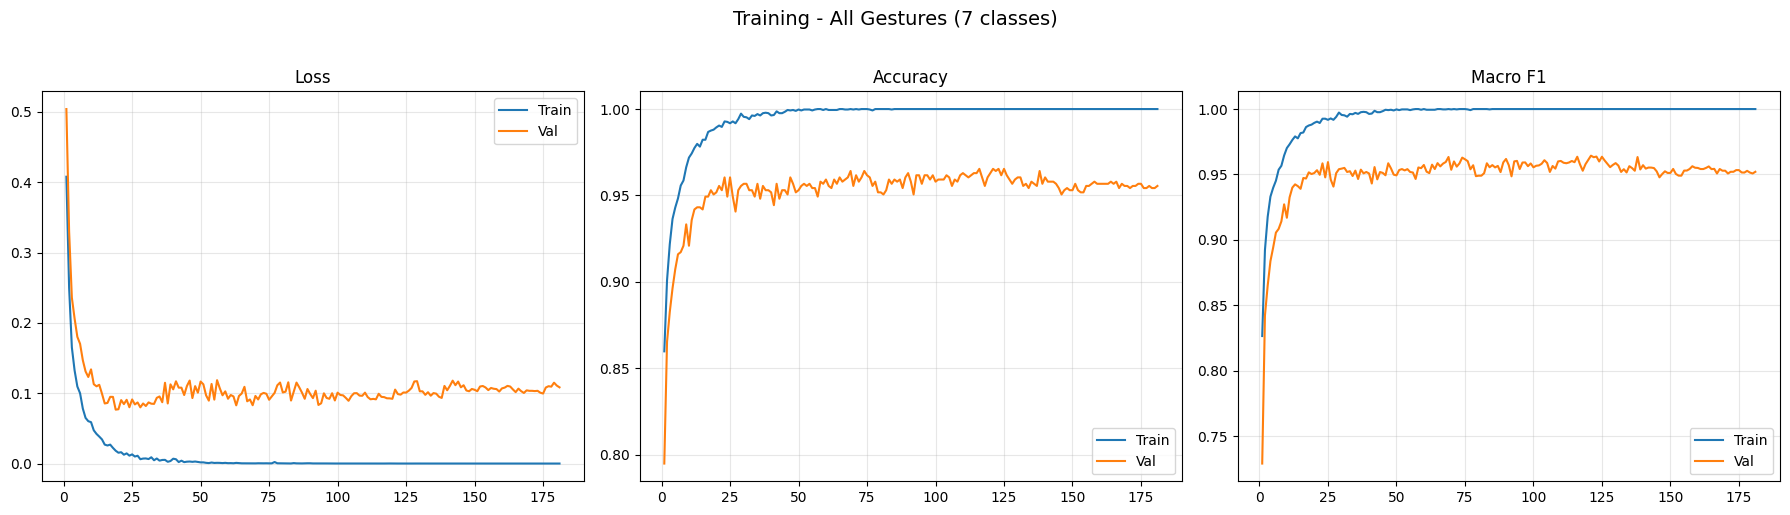

Training history saved → ..\visualizations\training\history_adam_optionals.npz  (Adam (Optionals, 7-class))


In [8]:
# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = np.arange(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train')
axes[1].plot(ep, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(ep, history['train_f1'], label='Train')
axes[2].plot(ep, history['val_f1'], label='Val')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.suptitle('Training - All Gestures (7 classes)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'learning_curves_optionals.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- O1.1: Save raw training history ----
save_training_history(
    history, EDA_DIR / 'history_adam_optionals.npz',
    model_name='Adam (Optionals, 7-class)',
    metadata={'architecture': str(model.layer_sizes), 'optimizer': 'adam', 'lr': 0.001}
)

TEST SET RESULTS (All Gestures)
  Loss     : 0.1604
  Accuracy : 0.9664
  Macro F1 : 0.9658

Class            Prec   Recall       F1  Support
------------------------------------------------
idle            0.966    0.968    0.967      408
r_ccw           0.970    0.985    0.977       66
r_cw            0.970    0.985    0.977       66
sd              0.952    0.894    0.922       66
sl              0.985    0.985    0.985       66
sr              0.985    0.985    0.985       66
su              0.940    0.955    0.947       66


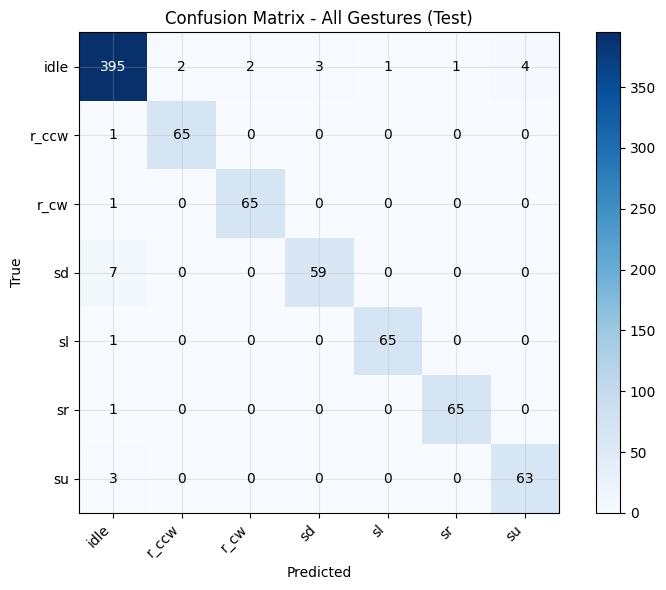

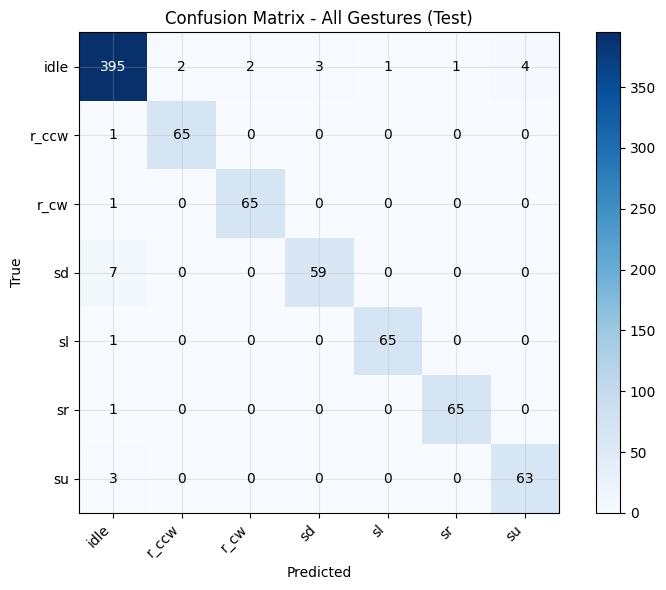

In [9]:
# Test evaluation
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

test_loss = ce_loss(y_test_proba, y_test_oh)
test_acc = accuracy_fn(y_test_pred, y_test_int)
test_f1 = f1_macro(y_test_pred, y_test_int, NUM_CLASSES)

print("=" * 50)
print("TEST SET RESULTS (All Gestures)")
print("=" * 50)
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Macro F1 : {test_f1:.4f}")
print("=" * 50)

# Per-class
print(f"\n{'Class':<12} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Support':>8}")
print("-" * 48)
for c in range(NUM_CLASSES):
    tp = np.sum((y_test_pred == c) & (y_test_int == c))
    fp = np.sum((y_test_pred == c) & (y_test_int != c))
    fn = np.sum((y_test_pred != c) & (y_test_int == c))
    support = np.sum(y_test_int == c)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{idx_to_label[c]:<12} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f} {support:>8d}")

# Confusion matrix (saved via save_path parameter)
cm = confusion_matrix_np(y_test_int, y_test_pred, NUM_CLASSES)
class_names = [idx_to_label[i] for i in range(NUM_CLASSES)]
plot_confusion_matrix(cm, class_names=class_names,
                      title='Confusion Matrix - All Gestures (Test)',
                      save_path=EDA_DIR / 'confusion_matrix_optionals.png')

## Step 7: Save Model Weights (All Gestures)

These weights are used for M3 (live video with all gestures).

In [10]:
SAVE_DIR = Path('.')
OPTIONALS_DIR = PROCESSED_DIR / 'optionals'
OPTIONALS_DIR.mkdir(parents=True, exist_ok=True)

# Model weights
weights_path = SAVE_DIR / 'model_weights_optionals.npz'
np.savez(
    weights_path,
    **{f'W{i}': w for i, w in enumerate(model.weights)},
    **{f'b{i}': b for i, b in enumerate(model.biases)},
    layer_sizes=np.array(model.layer_sizes),
)
print(f"Saved model weights -> {weights_path}")

# Scaler
scaler_path = SAVE_DIR / 'scaler_params_optionals.npz'
np.savez(scaler_path, mean=train_mean, std=train_std)
print(f"Saved scaler -> {scaler_path}")

# Label mapping
labels_path = SAVE_DIR / 'label_mapping_optionals.npz'
np.savez(
    labels_path,
    labels=np.array(list(label_to_idx.keys())),
    indices=np.array(list(label_to_idx.values())),
)
print(f"Saved label mapping -> {labels_path}")
print(f"  Classes: {label_to_idx}")

# Copy to data/processed/optionals/ with generic names (matching pipeline expectations)
import shutil
name_map = {
    'model_weights_optionals.npz': 'model_weights.npz',
    'scaler_params_optionals.npz': 'scaler_params.npz',
    'label_mapping_optionals.npz': 'label_mapping.npz',
}
for src in [weights_path, scaler_path, labels_path]:
    dest = OPTIONALS_DIR / name_map[src.name]
    shutil.copy2(src, dest)
print(f"\nCopied to {OPTIONALS_DIR}")
print("All model artifacts saved.")

Saved model weights -> model_weights_optionals.npz
Saved scaler -> scaler_params_optionals.npz
Saved label mapping -> label_mapping_optionals.npz
  Classes: {np.str_('idle'): 0, np.str_('r_ccw'): 1, np.str_('r_cw'): 2, np.str_('sd'): 3, np.str_('sl'): 4, np.str_('sr'): 5, np.str_('su'): 6}

Copied to ..\data\processed\optionals
All model artifacts saved.


## Step 8: O1.1 — Cross-Model Comparison

Load histories from both the mandatory (4-class) and optionals (7-class) models
to compare their training dynamics side-by-side.

Found 1 saved training histories:
  history_adam_optionals.npz


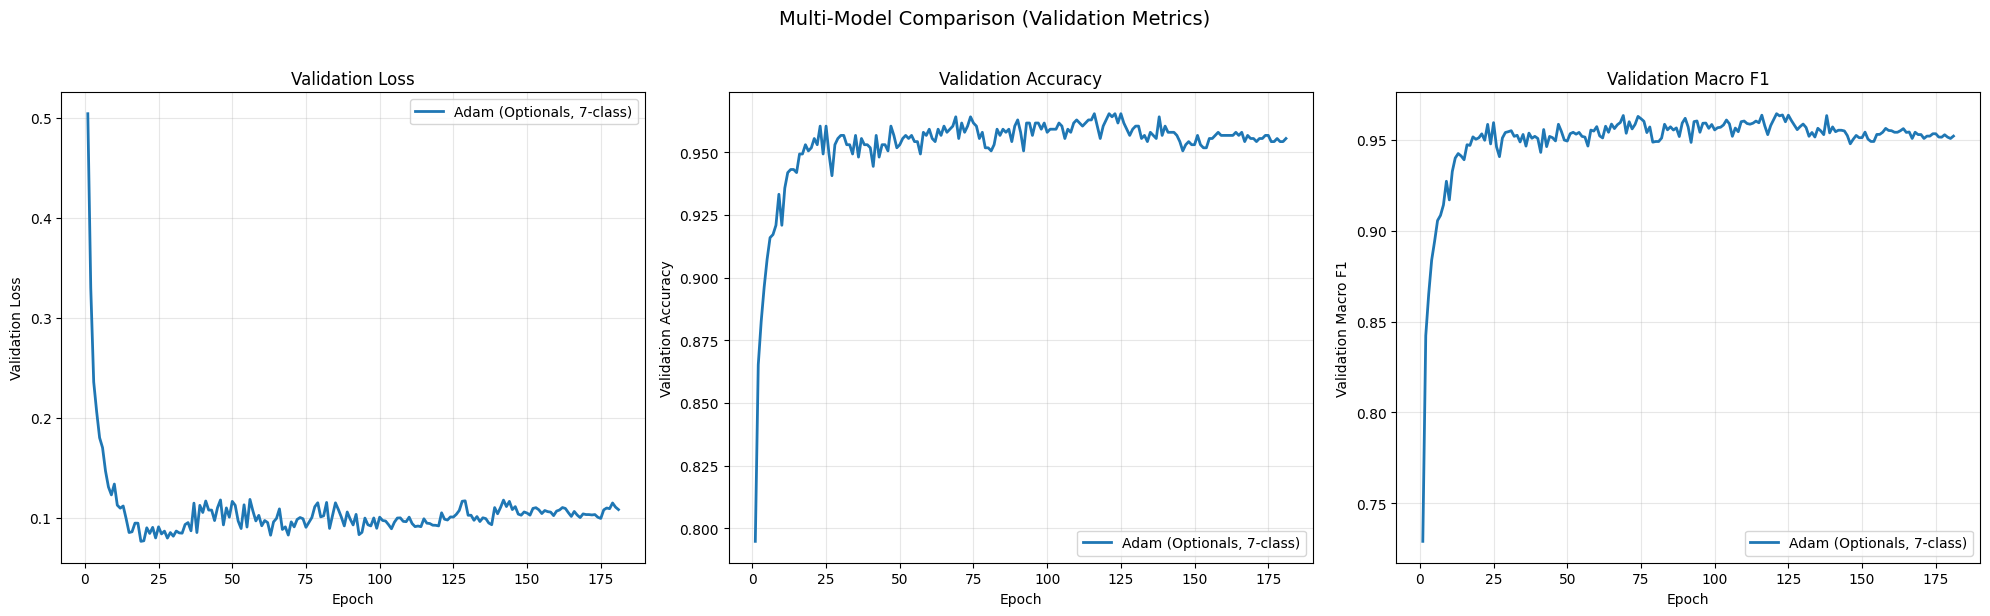

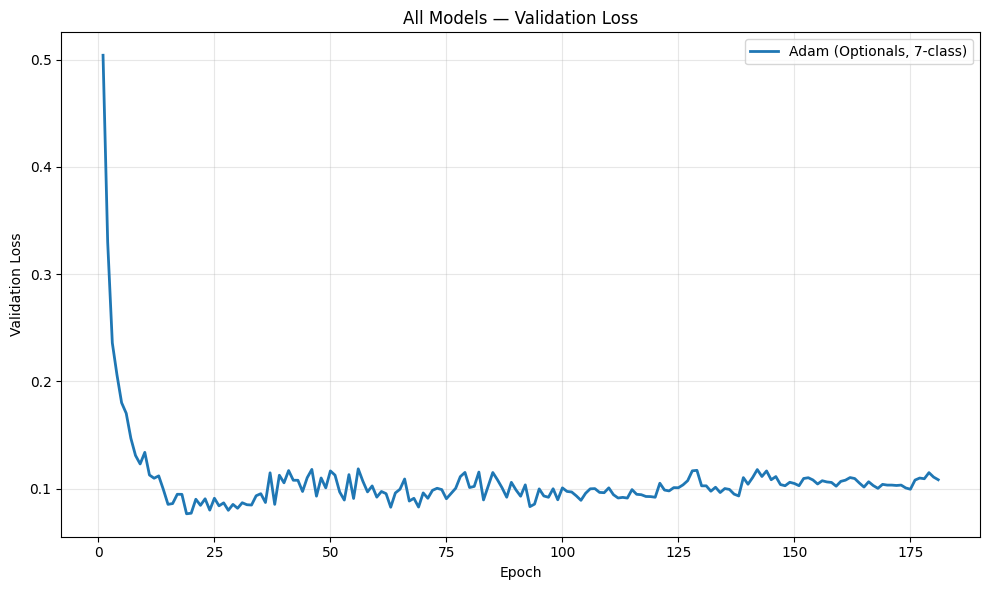

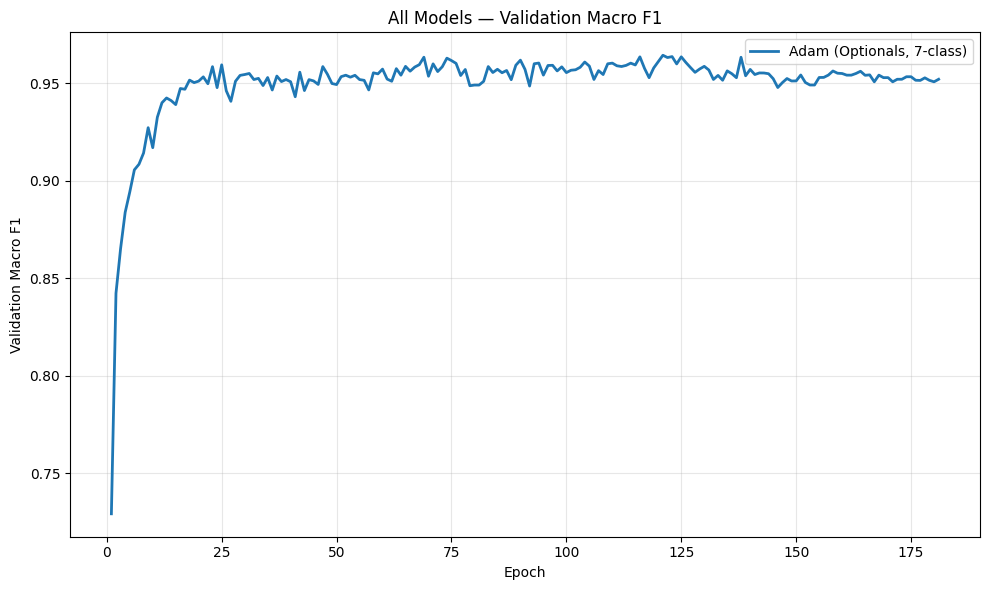


All O1.1 comparison visualizations saved to: C:\Users\Aswathy\Documents\jmu\WS25\ML Project\final_project_latest\final-submission\visualizations\training


In [11]:
# ---- O1.1: Load & compare mandatory vs optionals models ----
history_files = list(EDA_DIR.glob('history_*.npz'))
print(f"Found {len(history_files)} saved training histories:")
for f in sorted(history_files):
    print(f"  {f.name}")

# Load all available histories
histories = load_multiple_histories(*sorted(history_files))

# Generate combined multi-model summary
plot_multi_model_summary(
    histories,
    save_path=EDA_DIR / 'multi_model_comparison_all.png'
)

# Individual metric comparisons
plot_model_comparison(
    histories, metric='val_loss',
    title='All Models — Validation Loss',
    save_path=EDA_DIR / 'comparison_val_loss_all.png'
)
plot_model_comparison(
    histories, metric='val_f1',
    title='All Models — Validation Macro F1',
    save_path=EDA_DIR / 'comparison_val_f1_all.png'
)

print("\nAll O1.1 comparison visualizations saved to:", EDA_DIR.resolve())